In [37]:
import pandas as pd
import numpy as np
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
path = r'../../data/limpieza/cleaned_data.csv'
df = pd.read_csv(path, header=0)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df

,timestamp,open_binance,high_binance,low_binance,close_binance,volume_binance,trades_binance,volumen_binance,SMA_50_binance,SMA_200_binance,...,volatilidad_200_dxy,momentum_50_dxy,momentum_200_dxy,var_diaria_dxy,rango_dia_dxy,RSI_dxy,pct_cambio_7d,tendencia_futura_7d,pct_cambio_30d,tendencia_futura_30d
0,2023-01-30,23743.37,23800.51,22500.00,22826.15,302405.90121,7790224.0,6.902762e+09,18840.4428,19681.15235,...,3.344820,-2.743332,-6.260002,0.114196,0.649994,48.159051,0.887539,1,15.651634,1
1,2023-01-31,22827.38,23320.00,22714.77,23125.13,264649.34909,6798411.0,6.120051e+09,18958.7488,19692.62780,...,3.365946,-3.029999,-5.959999,-0.175988,0.599998,42.076453,0.651979,1,14.475111,1
2,2023-02-01,23125.13,23812.66,22760.23,23732.66,310790.42271,7863213.0,7.375883e+09,19077.9080,19705.31310,...,3.394349,-2.760002,-6.609998,-0.861897,1.150002,28.731297,-0.237540,-1,12.944154,1
3,2023-02-02,23731.41,24255.00,23363.27,23488.94,364177.20751,9102300.0,8.554137e+09,19191.6238,19718.76700,...,3.417732,-2.019997,-5.850001,0.523611,1.090004,44.673560,-1.569186,-1,11.529444,1
4,2023-02-03,23489.33,23715.70,23204.62,23431.90,332571.02904,8007846.0,7.792771e+09,19313.1350,19723.76360,...,3.432184,-1.639999,-4.450005,1.149875,1.459999,61.290298,-2.890628,-1,10.208064,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
737,2025-02-05,97763.14,99149.00,96155.00,96612.43,26233.30444,4471763.0,2.534463e+09,98831.5984,78366.38690,...,2.801588,0.620003,3.210002,-0.351980,0.709999,43.123575,-3.443442,-1,-7.038993,-1
738,2025-02-06,96612.44,99120.00,95676.64,96554.35,23515.20405,4242807.0,2.270495e+09,98758.6052,78508.33195,...,2.808863,-0.339996,3.350004,0.102250,0.559998,45.794384,-2.297581,-1,-7.370303,-1
739,2025-02-07,96554.35,100137.99,95620.34,96506.80,31794.22065,5012456.0,3.068358e+09,98739.5040,78653.20590,...,2.817887,-0.370003,3.730003,0.325006,0.800003,57.462674,-1.310774,-1,-7.939256,-1
740,2025-02-08,96506.80,96880.00,95688.00,96444.74,10147.24294,1757892.0,9.786482e+08,98712.2900,78805.74955,...,2.827413,0.513331,3.683337,0.086387,0.650004,58.905243,-0.540410,-1,-8.600834,-1


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 94 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   timestamp                  742 non-null    datetime64[ns]
 1   open_binance               742 non-null    float64       
 2   high_binance               742 non-null    float64       
 3   low_binance                742 non-null    float64       
 4   close_binance              742 non-null    float64       
 5   volume_binance             742 non-null    float64       
 6   trades_binance             742 non-null    float64       
 7   volumen_binance            742 non-null    float64       
 8   SMA_50_binance             742 non-null    float64       
 9   SMA_200_binance            742 non-null    float64       
 10  EMA_50_binance             742 non-null    float64       
 11  EMA_200_binance            742 non-null    float64       
 12  var_diar

In [43]:
df.describe()

,timestamp,open_binance,high_binance,low_binance,close_binance,volume_binance,trades_binance,volumen_binance,SMA_50_binance,SMA_200_binance,...,volatilidad_200_dxy,momentum_50_dxy,momentum_200_dxy,var_diaria_dxy,rango_dia_dxy,RSI_dxy,pct_cambio_7d,tendencia_futura_7d,pct_cambio_30d,tendencia_futura_30d
count,742,742.000000,742.000000,742.000000,742.000000,742.000000,7.420000e+02,7.420000e+02,742.000000,742.000000,...,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000
mean,2024-02-04 12:00:00,51212.485108,52244.789677,50223.152453,51310.487790,58300.760190,2.629997e+06,2.338777e+09,48677.946712,41994.303261,...,1.809083,0.339281,-0.707702,0.008242,0.600047,52.691260,1.506569,0.161725,6.771095,0.323450
min,2023-01-30 00:00:00,20150.690000,20367.780000,19549.090000,20150.690000,7047.904300,3.108520e+05,2.508957e+08,18840.442800,19681.152350,...,0.854975,-5.040001,-12.786664,-1.466972,0.189995,0.000000,-12.802918,-1.000000,-11.118419,-1.000000
25%,2023-08-03 06:00:00,28474.212500,29189.782500,28120.985000,28543.050000,23141.911818,9.934640e+05,1.002496e+09,28142.026550,26803.805775,...,1.240370,-1.415001,-2.317501,-0.125541,0.433752,37.436969,-2.067050,-1.000000,-2.397357,-1.000000
50%,2024-02-04 12:00:00,45117.785000,46882.260000,44224.350000,45699.325000,33011.633055,1.552403e+06,1.652498e+09,43060.673200,34271.128400,...,1.628493,0.451663,-0.233750,0.009722,0.550003,52.786559,0.807487,1.000000,3.859773,1.000000
75%,2024-08-07 18:00:00,66481.747500,67637.997500,65101.500000,66621.082500,50534.908205,3.267816e+06,2.715184e+09,64939.440850,61751.480375,...,1.831235,2.169790,1.889999,0.156691,0.722502,67.900537,3.947382,1.000000,13.829234,1.000000
max,2025-02-09 00:00:00,106143.820000,109588.000000,105321.490000,106143.820000,699360.934230,1.522359e+07,1.725352e+10,99340.804800,78961.183300,...,3.727969,6.133336,5.146662,1.614773,1.740005,96.323587,22.108965,1.000000,39.508978,1.000000
std,NaN,23744.672913,24284.629296,23196.087125,23781.186929,88639.796599,2.645500e+06,2.278566e+09,22253.179516,18363.579525,...,0.776259,2.369461,3.551559,0.307105,0.238967,19.308620,5.626825,0.987502,12.046046,0.946883


## 1. Conteo de nulos

<Axes: >

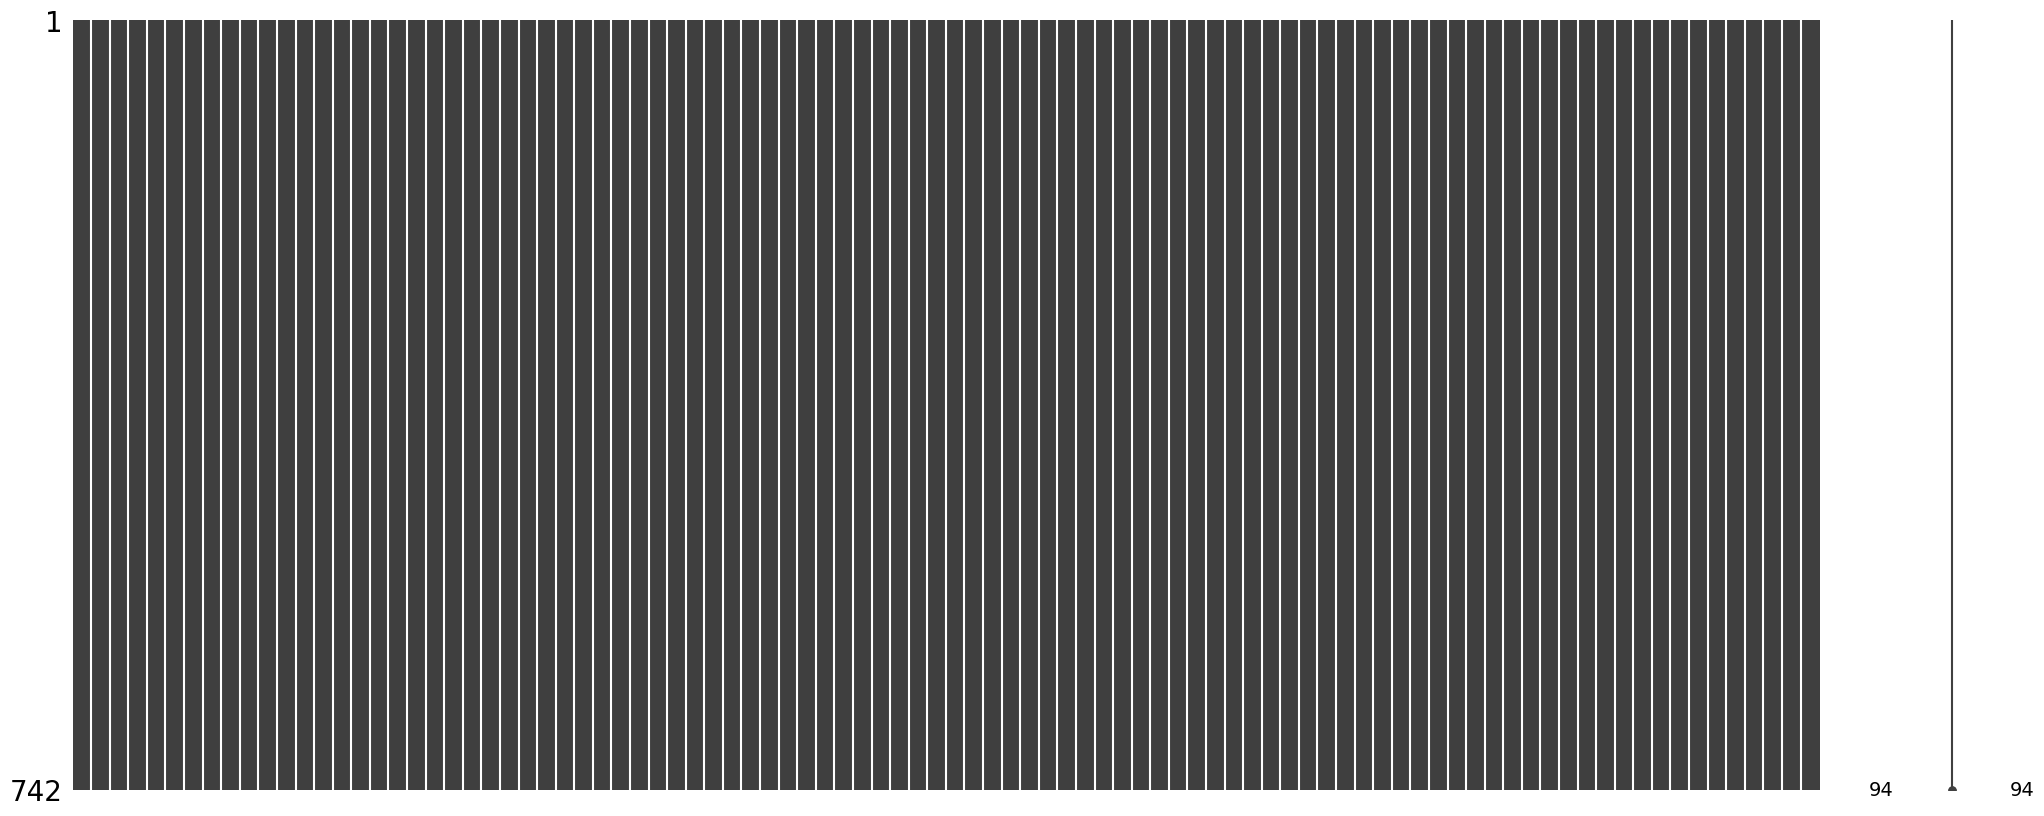

In [45]:
msno.matrix(df)

## 2. Correlaciones con las variables respuestas

### Relación precios de Bitcoin con otros activos (S&P 500, DXY, Nasdaq)

In [11]:
corr_matrix = df[['open_binance', 'high_binance', 'low_binance', 'close_binance', 'volumen_binance', 'trades_binance',
                 'close_sp500', 'high_sp500', 'low_sp500', 'open_sp500', 'volume_sp500',
                 'close_nasdaq', 'high_nasdaq', 'low_nasdaq', 'open_nasdaq', 'volume_nasdaq',
                 'close_dxy', 'high_dxy', 'low_dxy', 'open_dxy', 'pct_cambio_7d', 'pct_cambio_30d']].dropna().corr(method='pearson')

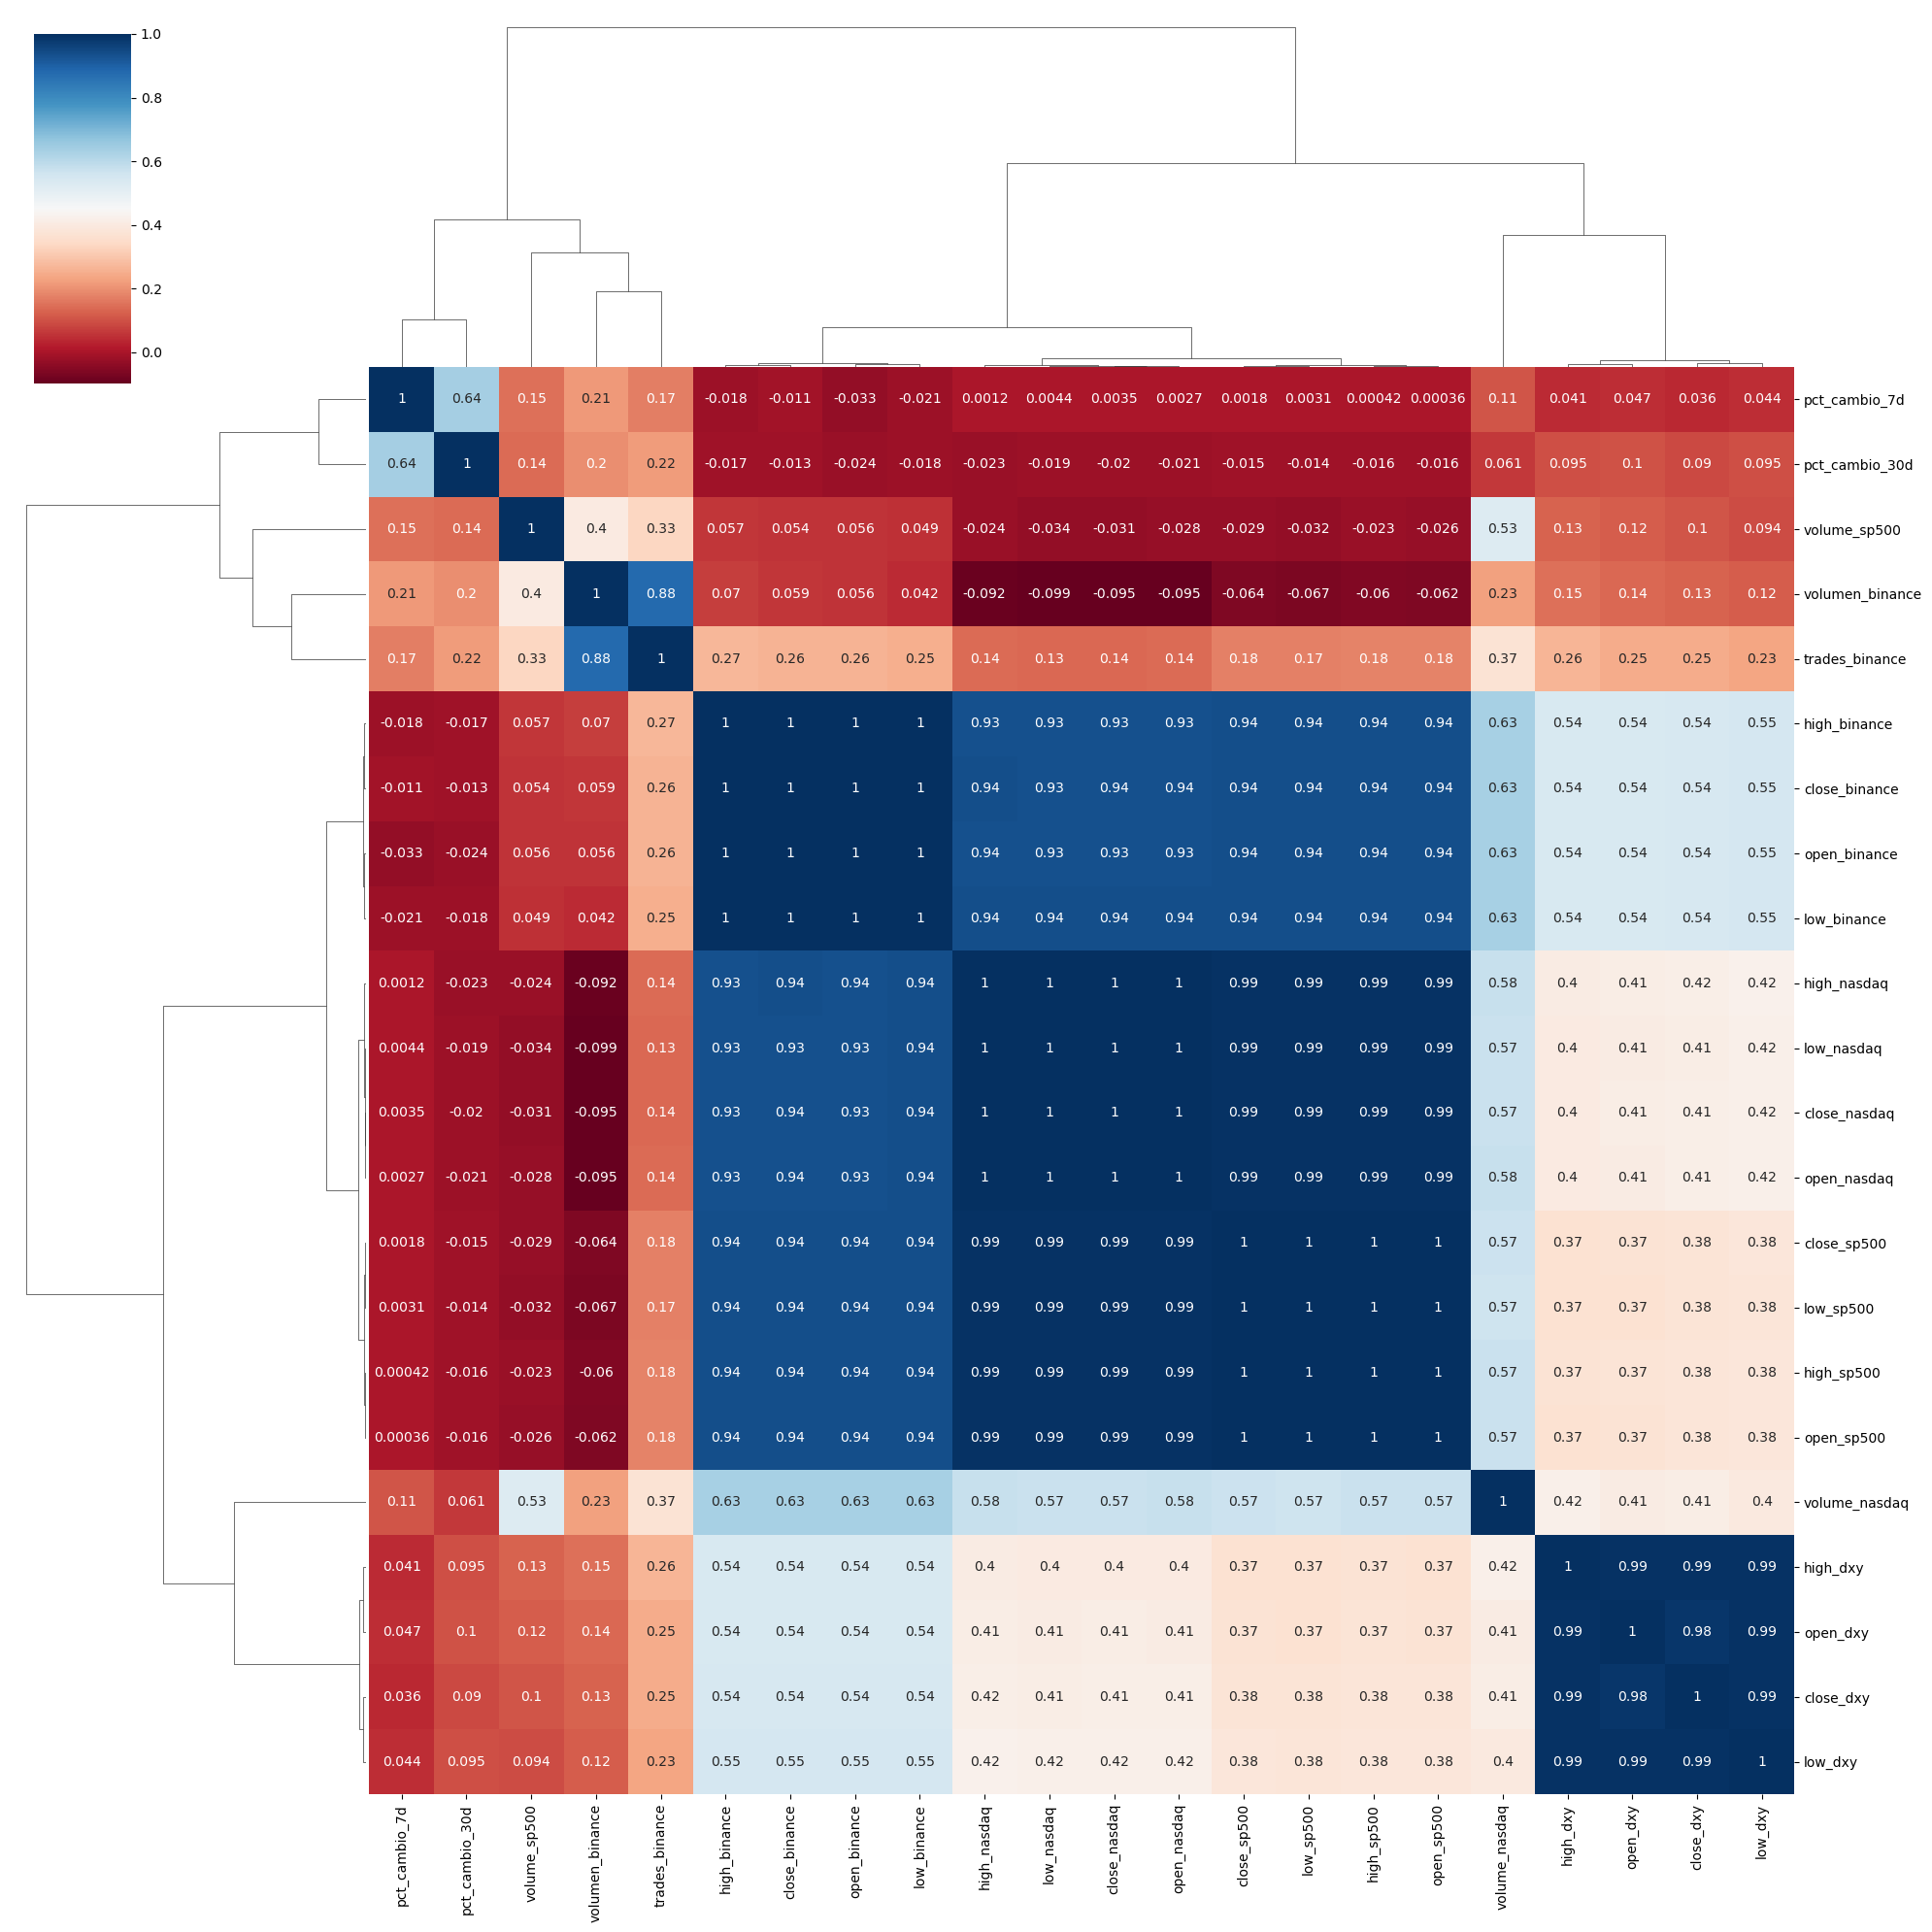

In [13]:
# Aplicar clustermap de la correlación
g = sns.clustermap(corr_matrix, 
                   method='complete',  # Método de enlace para la jerarquía
                   cmap='RdBu',         # Colormap
                   annot=True,          # Mostrar los valores de correlación en el mapa
                   annot_kws={'size': 10}, # Tamaño de la fuente de las anotaciones
                   figsize=(20, 20))     # Tamaño de la figura

# Mostrar el gráfico
plt.show()

### Tendencias en sentimientos del mercado (Fear & Greed Index, Google Trends)

In [15]:
corr_matrix = df[["close_binance", "volatilidad_50_binance", "volatilidad_200_binance", "var_diaria_binance",
                  "fear_greed_index_fg", "bitcoin_gtrends",
                  "close_sp500", "close_nasdaq", "close_dxy", 'pct_cambio_7d', 'pct_cambio_30d']].dropna().corr(method='spearman')

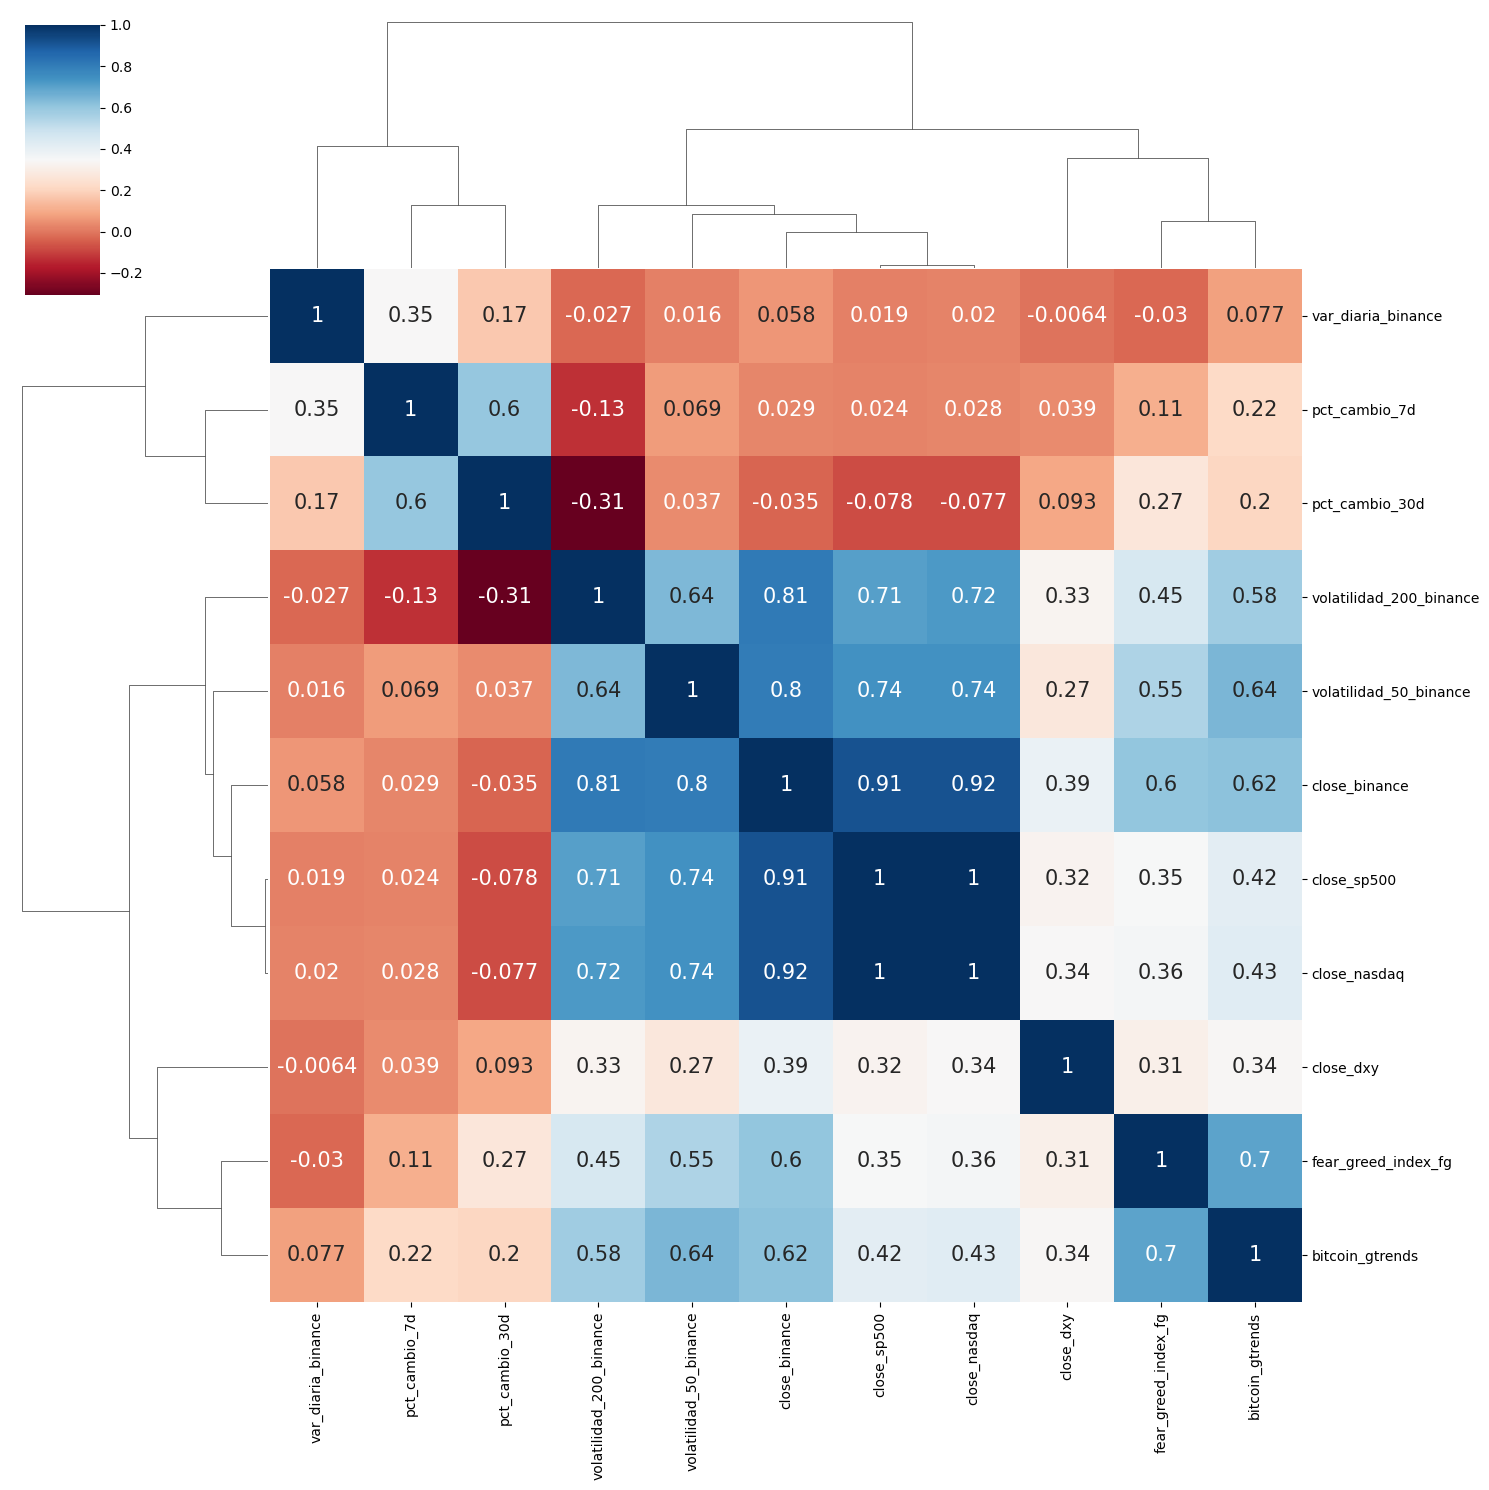

In [17]:
# Aplicar clustermap de la correlación
g = sns.clustermap(corr_matrix, 
                   method='complete',  # Método de enlace para la jerarquía
                   cmap='RdBu',         # Colormap
                   annot=True,          # Mostrar los valores de correlación en el mapa
                   annot_kws={'size': 15}, # Tamaño de la fuente de las anotaciones
                   figsize=(15, 15))     # Tamaño de la figura

# Mostrar el gráfico
plt.show()

### Relación entre volatilidad y precio

In [19]:
df_filtered = df[['timestamp', 'close_binance', 'volatilidad_50_binance', 'volatilidad_200_binance', 'var_diaria_binance']].dropna()

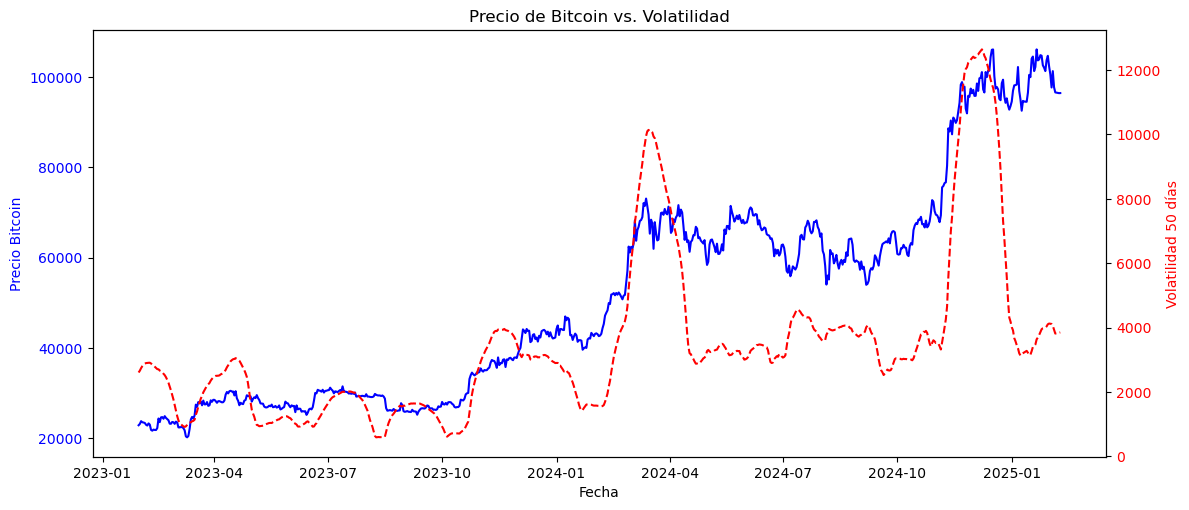

In [21]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# Gráfica de precio (eje izquierdo)
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Precio Bitcoin', color='blue')
ax1.plot(df_filtered['timestamp'], df_filtered['close_binance'], color='blue', label='Precio BTC')
ax1.tick_params(axis='y', labelcolor='blue')

# Agregar segundo eje Y para volatilidad
ax2 = ax1.twinx()
ax2.set_ylabel('Volatilidad 50 días', color='red')
ax2.plot(df_filtered['timestamp'], df_filtered['volatilidad_50_binance'], color='red', linestyle='dashed', label='Volatilidad 50 días')
ax2.tick_params(axis='y', labelcolor='red')

fig.tight_layout()
plt.title("Precio de Bitcoin vs. Volatilidad")
plt.show()

In [23]:
corr_matrix = df_filtered.drop(columns=['timestamp']).corr(method='spearman')  # Spearman capta relaciones no lineales

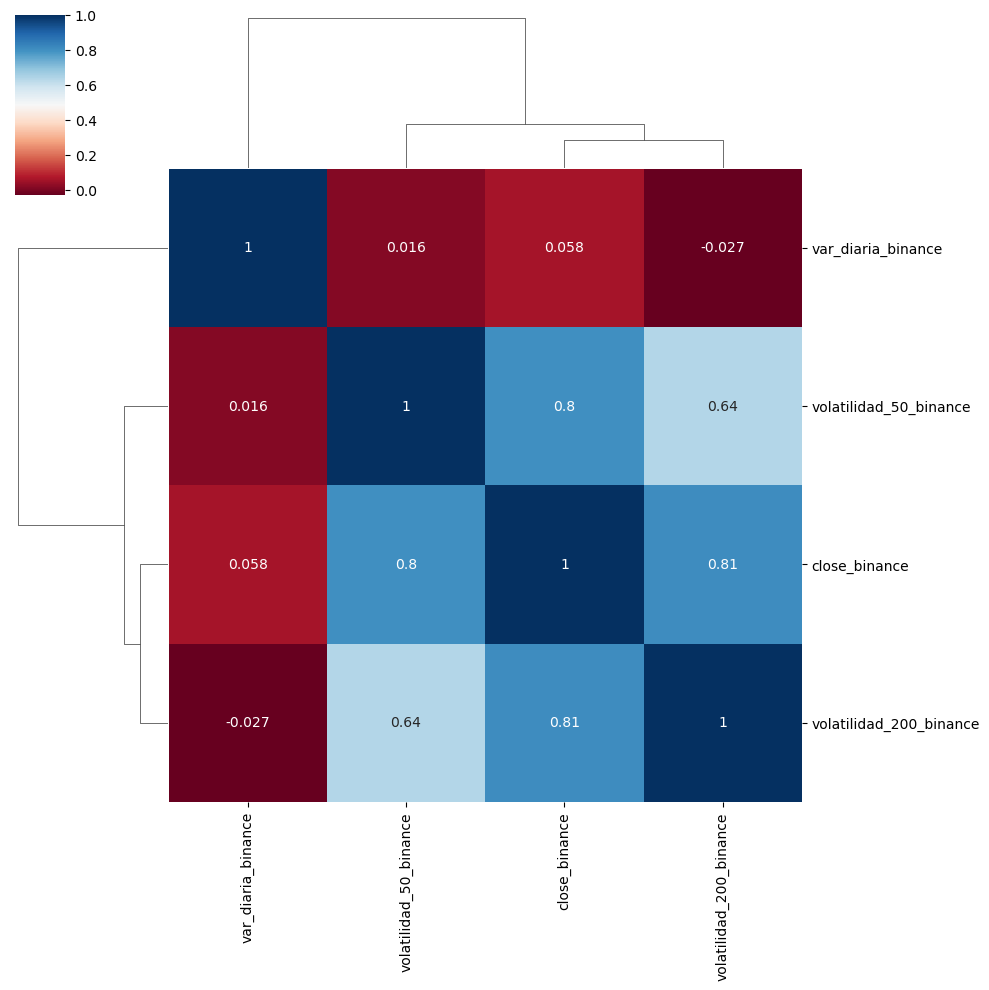

In [25]:
# Aplicar clustermap de la correlación
g = sns.clustermap(corr_matrix, 
                   method='complete',  # Método de enlace para la jerarquía
                   cmap='RdBu',         # Colormap
                   annot=True,          # Mostrar los valores de correlación en el mapa
                   annot_kws={'size': 10}, # Tamaño de la fuente de las anotaciones
                   figsize=(10, 10))     # Tamaño de la figura

# Mostrar el gráfico
plt.show()